<a href="https://colab.research.google.com/github/UXDynamicSolution/MineriaDatosDuocPAO/blob/main/afp_modelo_proyeccion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install yfinance

import yfinance as yf
import pandas as pd
from datetime import datetime
import time

In [ ]:

pd.set_option('display.max_rows', None)           # Mostrar todas las filas
pd.set_option('display.max_columns', None)         # Mostrar todas las columnas
pd.set_option('display.width', None)               # No cortar el ancho
pd.set_option('display.max_colwidth', None)        # Mostrar texto completo en las celdas
pd.set_option('display.expand_frame_repr', False)  # No dividir el dataframe en varias líneas
pd.set_option('max_seq_item', None)                # Mostrar secuencias completas (listas dentro del df)

In [ ]:
import yfinance as yf
import pandas as pd
import time
from datetime import datetime

# --- Tickers organizados ---
tickers_renta_variable = ["SPY", "IVV", "VTI", "QQQ", "EEM", "IWM", "ACWI", "^GSPC", "^IXIC", "^RUT", "^VIX"]
tickers_renta_fija = ["BND", "AGG", "TLT", "LQD", "IEF", "SHY", "TIP"] # TIP: Bonos protegidos contra inflacion
tickers_alternativos = ["GLD", "SLV", "USO", "BNO", "VNQ"] # USO: Petroleo WTI, BNO: Petroleo Brent, VNQ: Sector Inmobiliario
tickers_extras = ["ILF", "EWZ", "EWW", "FXI", "INDA", "EWJ", "VGK", "VPL"]
tickers_commodities = ["CPER", "DBC", "DBA", "LIT", "COPX", "URNM"] # COPX: Mineros de cobre, URNM: Uranio
tickers_divisas = ["CLP=X", "EURUSD=X", "CNY=X", "JPY=X", "BRL=X", "MXN=X"] # Peso Chileno, Euro, Yuan, Yen, Real, Peso Mexicano

tickers_final = tickers_renta_variable + tickers_renta_fija + tickers_alternativos + tickers_extras + tickers_commodities + tickers_divisas

print(f"Total de instrumentos a descargar: {len(tickers_final)}")

# --- Rango de fechas ---
inicio = "2008-05-01"
fin = "2026-04-20"
print(f"⏳ Descargando datos desde {inicio} hasta {fin}...\n")

# --- Descarga uno por uno ---
df_final = pd.DataFrame()
tickers_con_datos = []
tickers_sin_datos = []

for ticker in tickers_final:
    try:
        print(f"⬇Descargando {ticker}...")
        data = yf.download(ticker, start=inicio, end=fin, interval="1mo", progress=False, auto_adjust=True)
        time.sleep(2)  # evita bloqueos
        if not data.empty and 'Close' in data.columns:
            df_final[ticker] = data['Close']
            tickers_con_datos.append(ticker)
            print(f"{ticker} OK")
        else:
            tickers_sin_datos.append(ticker)
            print(f"{ticker} sin datos")
    except Exception as e:
        tickers_sin_datos.append(ticker)
        print(f"Error con {ticker}: {e}")
        time.sleep(5)

# --- Mostrar resultados ---
print(f"\n✅ Tickers descargados correctamente: {len(tickers_con_datos)}")
print(tickers_con_datos)

if tickers_sin_datos:
    print(f"\n⚠️ Tickers fallidos o sin datos: {len(tickers_sin_datos)}")
    print(tickers_sin_datos)

# --- Guardar si hay datos
if not df_final.empty:
    df_final.to_csv("historico_fondos_inversion_afp.csv")
    print("\n Archivo guardado: historico_fondos_inversion_afp.csv")
else:
    print("\n El DataFrame esta vacio. No se guardo el archivo.")

🎯 Total de instrumentos a descargar: 43
⏳ Descargando datos desde 2008-05-01 hasta 2026-04-20...

⬇️ Descargando SPY...
✅ SPY OK
⬇️ Descargando IVV...
✅ IVV OK
⬇️ Descargando VTI...
✅ VTI OK
⬇️ Descargando QQQ...
✅ QQQ OK
⬇️ Descargando EEM...
✅ EEM OK
⬇️ Descargando IWM...
✅ IWM OK
⬇️ Descargando ACWI...
✅ ACWI OK
⬇️ Descargando ^GSPC...
✅ ^GSPC OK
⬇️ Descargando ^IXIC...
✅ ^IXIC OK
⬇️ Descargando ^RUT...
✅ ^RUT OK
⬇️ Descargando ^VIX...
✅ ^VIX OK
⬇️ Descargando BND...
✅ BND OK
⬇️ Descargando AGG...
✅ AGG OK
⬇️ Descargando TLT...
✅ TLT OK
⬇️ Descargando LQD...
✅ LQD OK
⬇️ Descargando IEF...
✅ IEF OK
⬇️ Descargando SHY...
✅ SHY OK
⬇️ Descargando TIP...
✅ TIP OK
⬇️ Descargando GLD...
✅ GLD OK
⬇️ Descargando SLV...
✅ SLV OK
⬇️ Descargando USO...
✅ USO OK
⬇️ Descargando BNO...
✅ BNO OK
⬇️ Descargando VNQ...
✅ VNQ OK
⬇️ Descargando ILF...
✅ ILF OK
⬇️ Descargando EWZ...
✅ EWZ OK
⬇️ Descargando EWW...
✅ EWW OK
⬇️ Descargando FXI...
✅ FXI OK
⬇️ Descargando INDA...
✅ INDA OK
⬇️ Descargando EWJ

In [ ]:
df_final

,SPY,IVV,VTI,QQQ,EEM,IWM,ACWI,^GSPC,^IXIC,^RUT,...,DBA,LIT,COPX,URNM,CLP=X,EURUSD=X,CNY=X,JPY=X,BRL=X,MXN=X
Date,,,,,,,,,,,,,,,,,,,,,
2008-05-01,100.996277,100.692917,50.776127,43.100632,34.372299,58.376431,38.239120,1400.380005,2522.659912,748.280029,...,29.816870,NaN,NaN,NaN,470.000000,1.555791,6.9325,105.430000,1.6225,10.326000
2008-06-01,92.094788,91.806320,46.432800,38.929321,30.832834,53.982761,35.184834,1280.000000,2292.979980,689.659973,...,34.312599,NaN,NaN,NaN,524.799988,1.575002,6.8444,106.120003,1.5910,10.299000
2008-07-01,91.723732,91.561760,46.361526,39.206604,29.469667,55.757450,34.074192,1267.380005,2325.550049,714.520020,...,30.778435,NaN,NaN,NaN,499.790009,1.559308,6.8215,107.809998,1.5618,10.030100
2008-08-01,93.141220,92.923836,47.038513,39.775806,27.608431,57.966587,33.504623,1282.829956,2367.520020,739.500000,...,29.833740,NaN,NaN,NaN,507.570007,1.469508,6.8252,108.430000,1.6307,10.274200
2008-09-01,83.884216,84.189278,42.481701,33.557602,23.555056,53.360344,29.396648,1166.359985,2091.879883,679.580017,...,25.481407,NaN,NaN,NaN,557.809998,1.409642,6.8351,106.070000,1.9220,10.930500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-01,681.376587,682.639099,335.358765,618.453186,53.553616,247.478394,140.237885,6849.089844,23365.689453,2500.429932,...,25.500341,63.288143,62.826866,53.769039,926.880005,1.159689,7.0758,156.149994,5.3554,18.280001
2025-12-01,679.910889,680.710999,334.321686,613.519531,53.938110,244.901642,140.257706,6845.500000,23241.990234,2481.909912,...,24.631670,64.684357,70.145264,53.091969,899.940002,1.174729,6.9961,156.412994,5.4762,17.978800
2026-01-01,691.969971,693.184692,340.570007,621.869995,59.099998,259.188934,145.500000,6939.029785,23461.820312,2613.739990,...,25.660000,69.949997,84.809998,74.360001,859.159973,1.185536,6.9480,154.740005,5.1892,17.451000


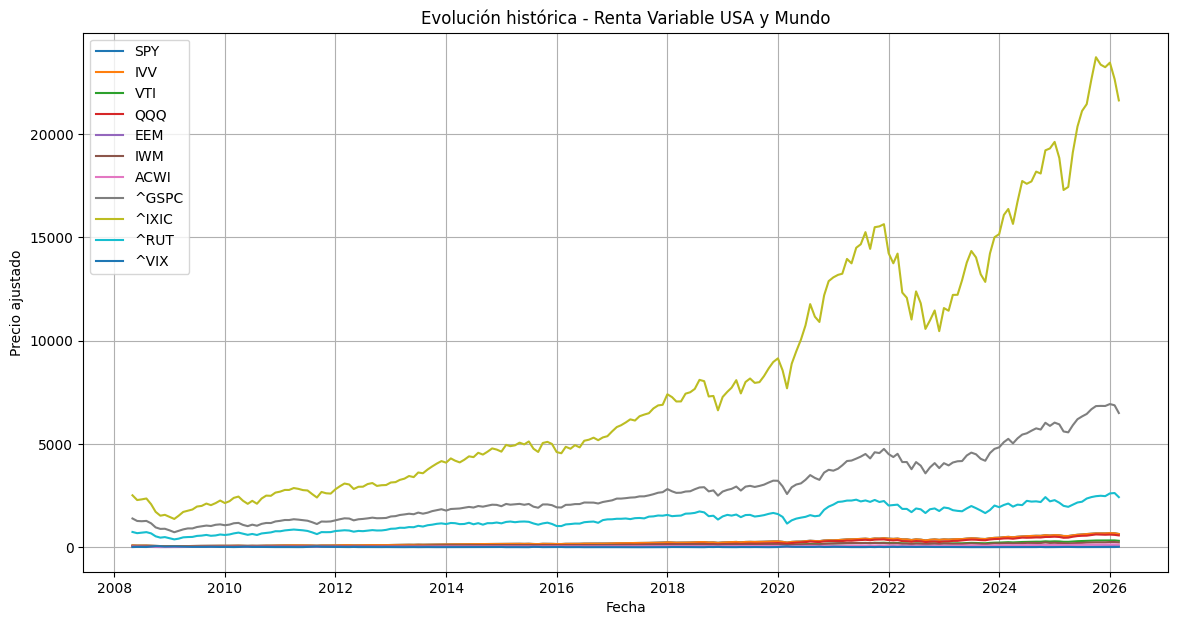

📊 Rendimiento promedio anualizado (Renta Variable USA y Mundo):

QQQ      15.71
^IXIC    12.81
IVV      11.03
SPY      10.99
VTI      10.88
^GSPC     8.99
IWM       8.29
ACWI      7.39
^RUT      6.84
EEM       2.74
^VIX      2.54
dtype: float64

------------------------------------------------------------



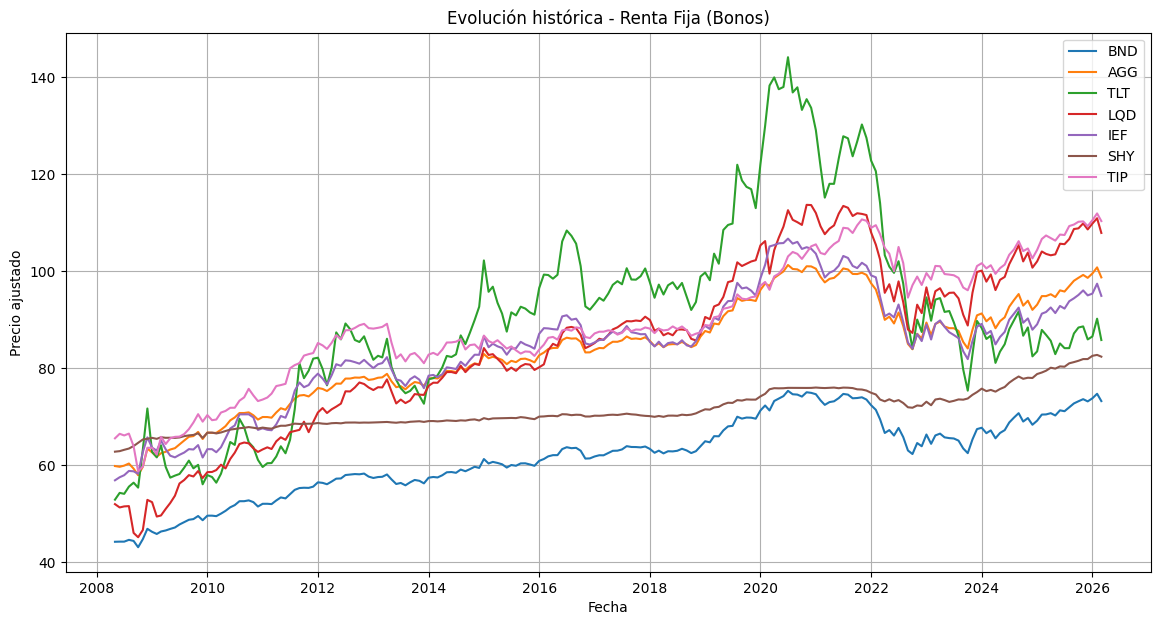

📊 Rendimiento promedio anualizado (Renta Fija (Bonos)):

LQD    4.18
TIP    2.96
IEF    2.91
BND    2.87
AGG    2.85
TLT    2.75
SHY    1.53
dtype: float64

------------------------------------------------------------



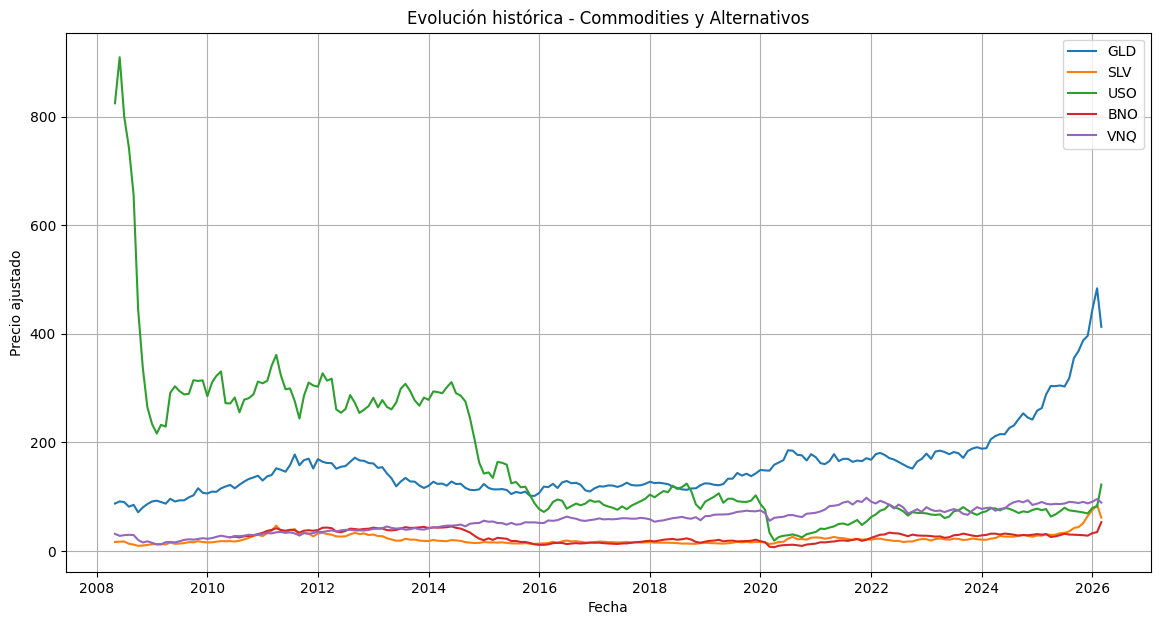

📊 Rendimiento promedio anualizado (Commodities y Alternativos):

GLD     9.09
SLV     7.60
VNQ     5.98
USO   -10.14
BNO      NaN
dtype: float64

------------------------------------------------------------



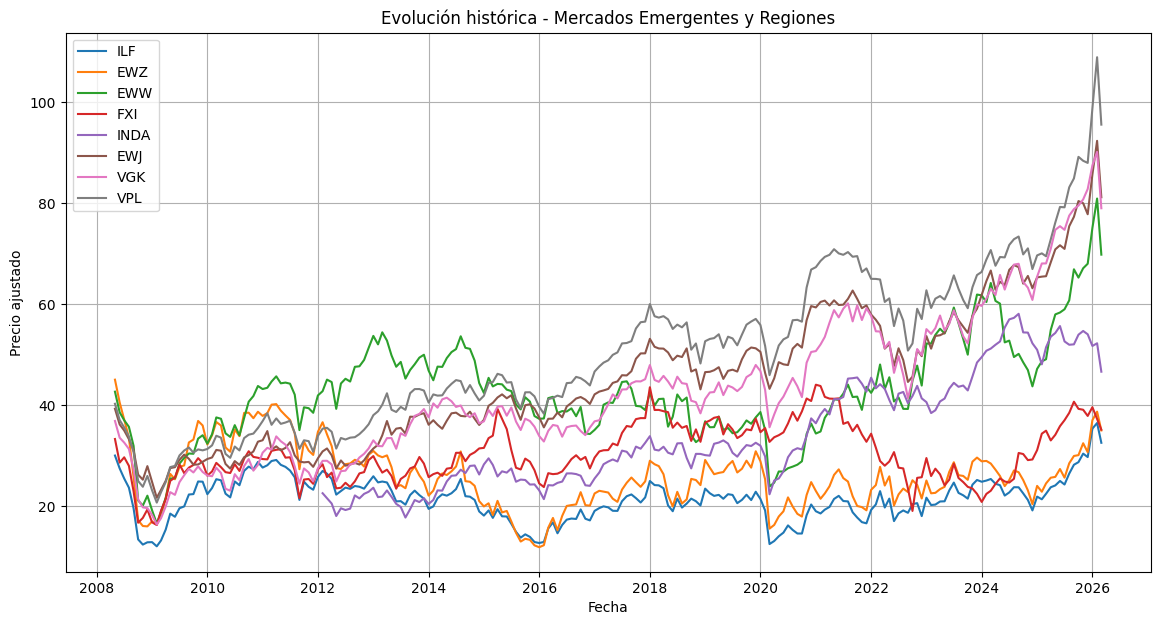

📊 Rendimiento promedio anualizado (Mercados Emergentes y Regiones):

VPL     4.96
VGK     4.37
EWJ     4.15
EWW     2.80
ILF     0.45
FXI     0.30
EWZ    -1.41
INDA     NaN
dtype: float64

------------------------------------------------------------



In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- Función para calcular rendimiento promedio anualizado ---
def calcular_rendimiento_promedio(df, anos):
    retornos = (df.iloc[-1] / df.iloc[0]) ** (1/anos) - 1
    return retornos * 100  # en %

# --- Definimos periodos ---
anos = (df_final.index[-1].year - df_final.index[0].year) + (df_final.index[-1].month - df_final.index[0].month) / 12

# --- Grupos separados ---
grupos = {
    "Renta Variable USA y Mundo": tickers_renta_variable,
    "Renta Fija (Bonos)": tickers_renta_fija,
    "Commodities y Alternativos": tickers_alternativos,
    "Mercados Emergentes y Regiones": tickers_extras
}

# --- Graficamos cada grupo ---

for nombre_grupo, tickers in grupos.items():
    plt.figure(figsize=(14,7))
    for ticker in tickers:
        if ticker in df_final.columns:
            plt.plot(df_final.index, df_final[ticker], label=ticker)

    plt.title(f'Evolución histórica - {nombre_grupo}')
    plt.xlabel('Fecha')
    plt.ylabel('Precio ajustado')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Cálculo de rendimiento promedio
    rendimientos = calcular_rendimiento_promedio(df_final[tickers], anos)
    print(f"📊 Rendimiento promedio anualizado ({nombre_grupo}):\n")
    print(rendimientos.round(2).sort_values(ascending=False))
    print("\n" + "-"*60 + "\n")


In [ ]:
tickers_final

['SPY',
 'IVV',
 'VTI',
 'QQQ',
 'EEM',
 'IWM',
 'ACWI',
 '^GSPC',
 '^IXIC',
 '^RUT',
 '^VIX',
 'BND',
 'AGG',
 'TLT',
 'LQD',
 'IEF',
 'SHY',
 'TIP',
 'GLD',
 'SLV',
 'USO',
 'BNO',
 'VNQ',
 'ILF',
 'EWZ',
 'EWW',
 'FXI',
 'INDA',
 'EWJ',
 'VGK',
 'VPL',
 'CPER',
 'DBC',
 'DBA',
 'LIT',
 'COPX',
 'URNM',
 'CLP=X',
 'EURUSD=X',
 'CNY=X',
 'JPY=X',
 'BRL=X',
 'MXN=X']

In [ ]:
df_final.shape

(215, 43)

In [ ]:
df_final

,SPY,IVV,VTI,QQQ,EEM,IWM,ACWI,^GSPC,^IXIC,^RUT,...,DBA,LIT,COPX,URNM,CLP=X,EURUSD=X,CNY=X,JPY=X,BRL=X,MXN=X
Date,,,,,,,,,,,,,,,,,,,,,
2008-05-01,100.996277,100.692917,50.776127,43.100632,34.372299,58.376431,38.239120,1400.380005,2522.659912,748.280029,...,29.816870,NaN,NaN,NaN,470.000000,1.555791,6.9325,105.430000,1.6225,10.326000
2008-06-01,92.094788,91.806320,46.432800,38.929321,30.832834,53.982761,35.184834,1280.000000,2292.979980,689.659973,...,34.312599,NaN,NaN,NaN,524.799988,1.575002,6.8444,106.120003,1.5910,10.299000
2008-07-01,91.723732,91.561760,46.361526,39.206604,29.469667,55.757450,34.074192,1267.380005,2325.550049,714.520020,...,30.778435,NaN,NaN,NaN,499.790009,1.559308,6.8215,107.809998,1.5618,10.030100
2008-08-01,93.141220,92.923836,47.038513,39.775806,27.608431,57.966587,33.504623,1282.829956,2367.520020,739.500000,...,29.833740,NaN,NaN,NaN,507.570007,1.469508,6.8252,108.430000,1.6307,10.274200
2008-09-01,83.884216,84.189278,42.481701,33.557602,23.555056,53.360344,29.396648,1166.359985,2091.879883,679.580017,...,25.481407,NaN,NaN,NaN,557.809998,1.409642,6.8351,106.070000,1.9220,10.930500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-01,681.376587,682.639099,335.358765,618.453186,53.553616,247.478394,140.237885,6849.089844,23365.689453,2500.429932,...,25.500341,63.288143,62.826866,53.769039,926.880005,1.159689,7.0758,156.149994,5.3554,18.280001
2025-12-01,679.910889,680.710999,334.321686,613.519531,53.938110,244.901642,140.257706,6845.500000,23241.990234,2481.909912,...,24.631670,64.684357,70.145264,53.091969,899.940002,1.174729,6.9961,156.412994,5.4762,17.978800
2026-01-01,691.969971,693.184692,340.570007,621.869995,59.099998,259.188934,145.500000,6939.029785,23461.820312,2613.739990,...,25.660000,69.949997,84.809998,74.360001,859.159973,1.185536,6.9480,154.740005,5.1892,17.451000


In [ ]:
df_final.isnull().sum()

,0
SPY,0
IVV,0
VTI,0
QQQ,0
EEM,0
IWM,0
ACWI,0
^GSPC,0
^IXIC,0
^RUT,0


In [ ]:
df_final_limpio = df_final.dropna()

In [ ]:
df_final_limpio.shape

(76, 43)

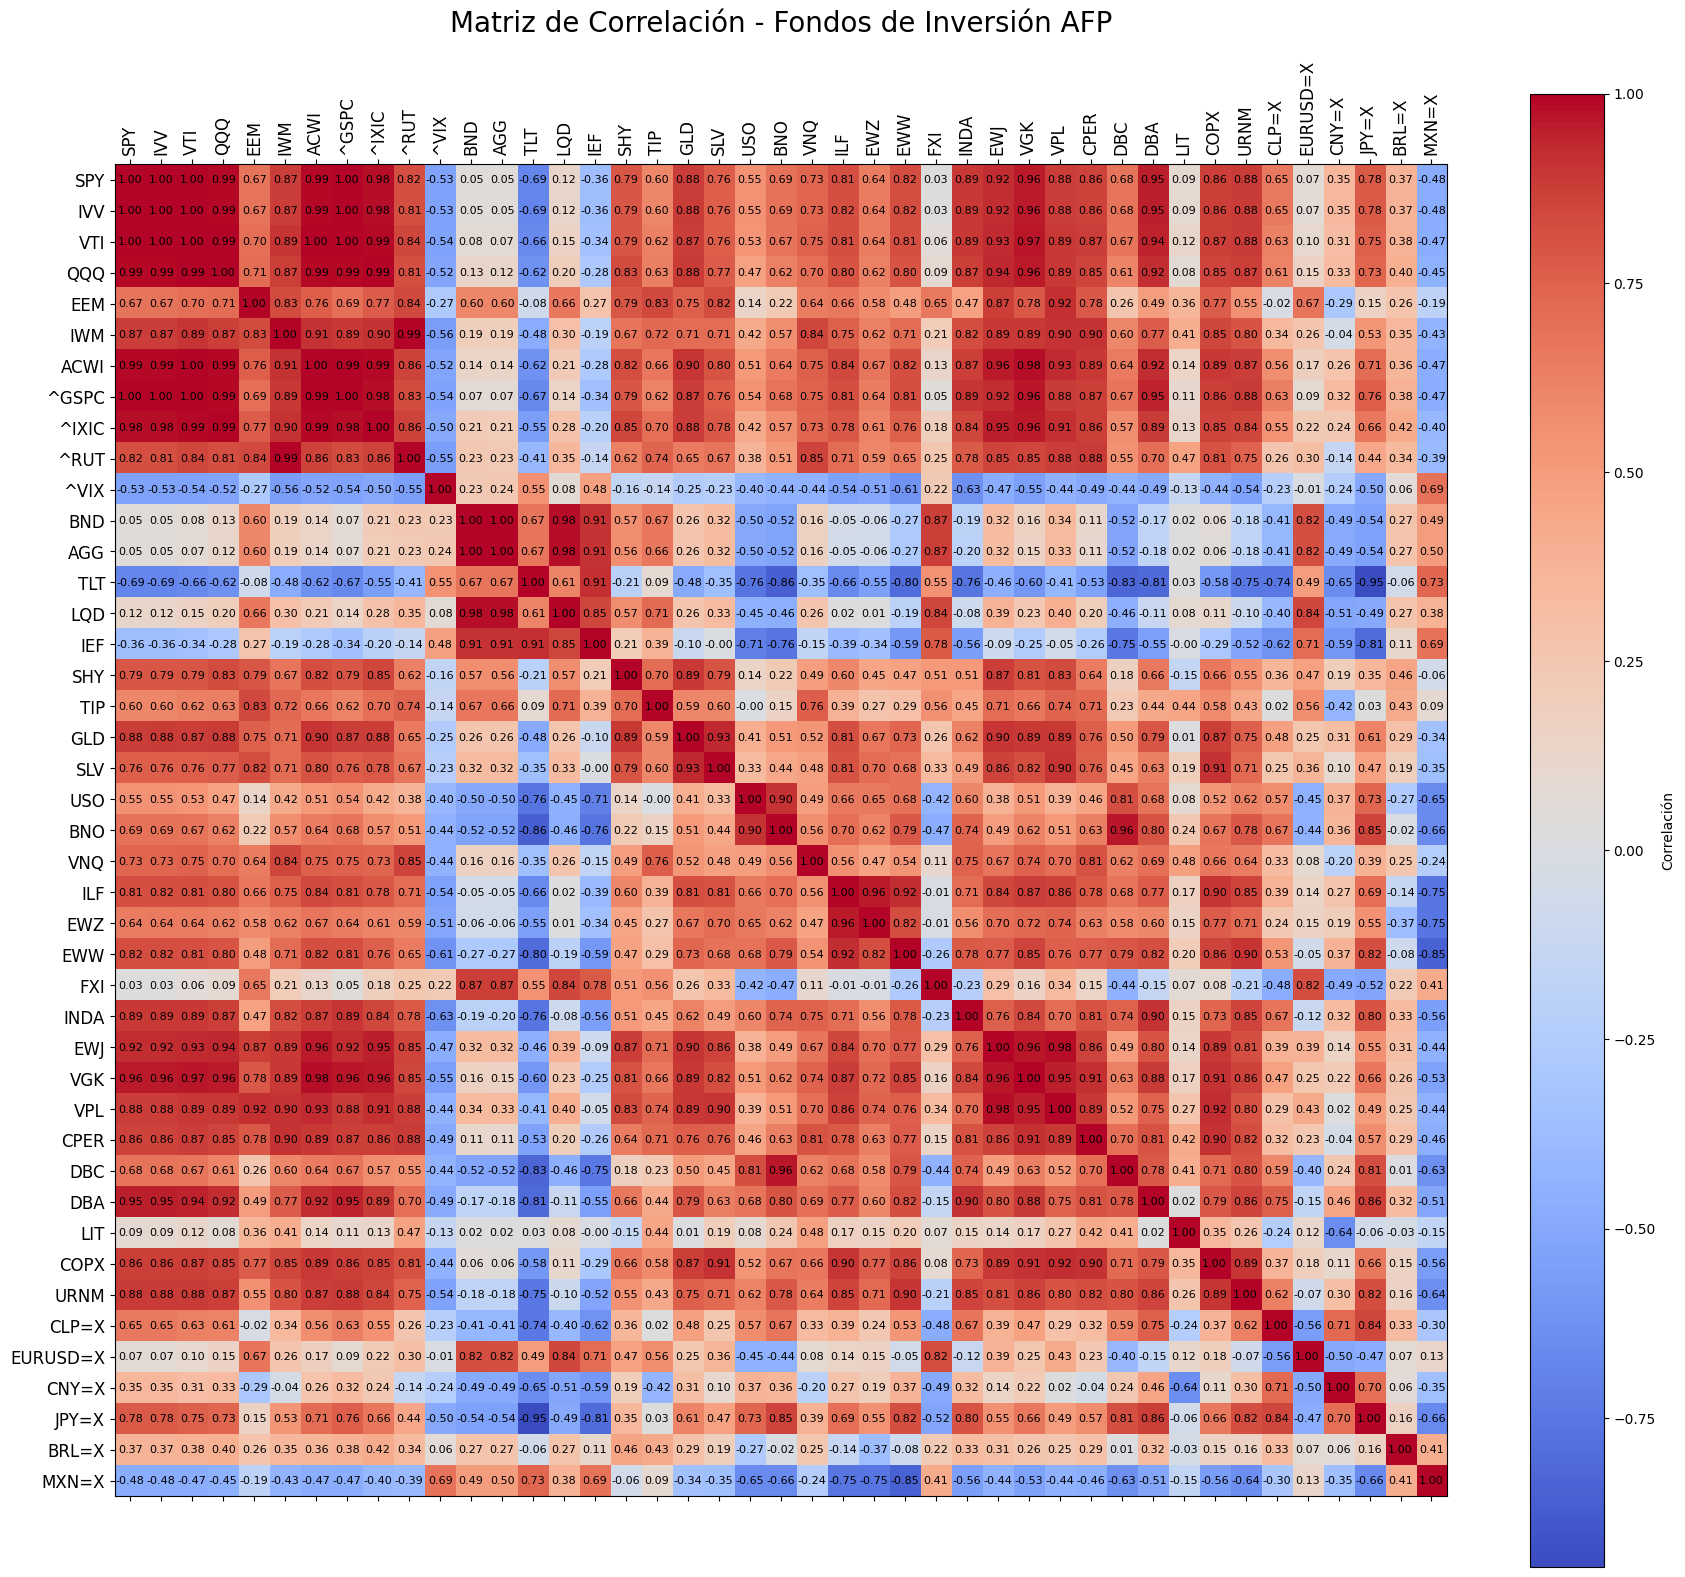

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

correlation_matrix = df_final_limpio.corr()

fig, ax = plt.subplots(figsize=(18, 16))  # Más grande

# Mostrar el mapa de calor
cax = ax.matshow(correlation_matrix, cmap='coolwarm')

# Añadir barra de color
fig.colorbar(cax, label="Correlación")

# Añadir etiquetas
ax.set_xticks(range(len(correlation_matrix.columns)))
ax.set_yticks(range(len(correlation_matrix.columns)))
ax.set_xticklabels(correlation_matrix.columns, rotation=90, fontsize=12)
ax.set_yticklabels(correlation_matrix.columns, fontsize=12)

# Mostrar los valores de correlación
for (i, j), val in np.ndenumerate(correlation_matrix):
    ax.text(j, i, f'{val:.2f}', ha='center', va='center', color='black', fontsize=8)

plt.title("Matriz de Correlación - Fondos de Inversión AFP", fontsize=20, pad=20)
plt.tight_layout()
plt.show()


In [ ]:
correlation_matrix

,SPY,IVV,VTI,QQQ,EEM,IWM,ACWI,^GSPC,^IXIC,^RUT,...,DBA,LIT,COPX,URNM,CLP=X,EURUSD=X,CNY=X,JPY=X,BRL=X,MXN=X
SPY,1.000000,0.999996,0.998730,0.991523,0.674298,0.872890,0.992058,0.999275,0.980165,0.815310,...,0.951857,0.090353,0.863923,0.884448,0.650828,0.066073,0.351732,0.777146,0.372199,-0.479926
IVV,0.999996,1.000000,0.998705,0.991535,0.674513,0.872625,0.992095,0.999244,0.980127,0.814973,...,0.951956,0.090284,0.864226,0.884491,0.650861,0.066305,0.351819,0.777278,0.372029,-0.479889
VTI,0.998730,0.998705,1.000000,0.992453,0.701616,0.894388,0.995372,0.999587,0.986056,0.841436,...,0.942856,0.117837,0.867557,0.881273,0.625267,0.097069,0.314040,0.753881,0.382420,-0.470911
QQQ,0.991523,0.991535,0.992453,1.000000,0.707933,0.869039,0.989666,0.992266,0.993421,0.814137,...,0.918297,0.078992,0.848867,0.867863,0.614028,0.148177,0.327284,0.732145,0.398486,-0.451225
EEM,0.674298,0.674513,0.701616,0.707933,1.000000,0.826114,0.758442,0.691115,0.771075,0.835842,...,0.493064,0.359831,0.765849,0.554919,-0.022107,0.670931,-0.288539,0.148547,0.264385,-0.186524
IWM,0.872890,0.872625,0.894388,0.869039,0.826114,1.000000,0.905030,0.886160,0.901968,0.993662,...,0.771252,0.411571,0.847208,0.801041,0.341959,0.260659,-0.042125,0.526741,0.349322,-0.426019
ACWI,0.992058,0.992095,0.995372,0.989666,0.758442,0.905030,1.000000,0.994068,0.988975,0.855763,...,0.921057,0.140484,0.890989,0.873837,0.564691,0.173804,0.262753,0.709536,0.356956,-0.469079
^GSPC,0.999275,0.999244,0.999587,0.992266,0.691115,0.886160,0.994068,1.000000,0.984408,0.832042,...,0.945452,0.109075,0.863989,0.880952,0.634105,0.085543,0.323010,0.758960,0.376446,-0.470224
^IXIC,0.980165,0.980127,0.986056,0.993421,0.771075,0.901968,0.988975,0.984408,1.000000,0.857059,...,0.885698,0.131918,0.851225,0.844888,0.550539,0.222459,0.238740,0.664392,0.421725,-0.401459
^RUT,0.815310,0.814973,0.841436,0.814137,0.835842,0.993662,0.855763,0.832042,0.857059,1.000000,...,0.703268,0.466946,0.806976,0.748100,0.258827,0.304592,-0.138120,0.441816,0.336691,-0.386426


In [ ]:
df_afp_historico = pd.read_csv('rentabilidad_afp_historico_corregido.csv')

In [ ]:
df_afp_historico

,anioo,mes,fondo,afp,periodo_actual,periodo_acumulado,ultimos_doce_meses,promedio_anual
0,2005,8,B,BANSANDER,-0.63,8.2,16.52,17.04
1,2005,8,B,CUPRUM,-0.62,8.1,16.33,17.18
2,2005,8,B,HABITAT,-0.84,7.35,15.12,15.67
3,2005,8,B,PLANVITAL,-0.79,7.57,15.08,14.33
4,2005,8,B,PROVIDA,-0.6,7.82,15.89,16.93
...,...,...,...,...,...,...,...,...
6751,2025,3,E,MODELO,0.94,1.47,1.45,NaN
6752,2025,3,E,PLANVITAL,1.2,2.11,1.43,3.2
6753,2025,3,E,PROVIDA,"1,00",1.64,0.85,3.17
6754,2025,3,E,UNO,1.03,1.95,1.36,NaN


In [ ]:
df_afp_historico.isnull().sum()

,0
anioo,0
mes,0
fondo,0
afp,0
periodo_actual,4
periodo_acumulado,28
ultimos_doce_meses,92
promedio_anual,964


In [ ]:
df_afp_historico.drop('periodo_acumulado', axis=1, inplace=True)
df_afp_historico.drop('ultimos_doce_meses', axis=1, inplace=True)
df_afp_historico.drop('promedio_anual', axis=1, inplace=True)
df_afp_historico.drop('afp', axis=1, inplace=True)


In [ ]:
df_afp_historico

,anioo,mes,fondo,periodo_actual
0,2005,8,B,-0.63
1,2005,8,B,-0.62
2,2005,8,B,-0.84
3,2005,8,B,-0.79
4,2005,8,B,-0.6
...,...,...,...,...
6751,2025,3,E,0.94
6752,2025,3,E,1.2
6753,2025,3,E,"1,00"
6754,2025,3,E,1.03


In [ ]:
df_afp_historico_limpio = df_afp_historico.dropna()

In [ ]:
df_afp_historico_limpio['fondo'].value_counts()

,count
fondo,
B,1688
C,1688
D,1688
E,1688


In [ ]:
df_afp_historico_limpio

,anioo,mes,fondo,periodo_actual
0,2005,8,B,-0.63
1,2005,8,B,-0.62
2,2005,8,B,-0.84
3,2005,8,B,-0.79
4,2005,8,B,-0.6
...,...,...,...,...
6751,2025,3,E,0.94
6752,2025,3,E,1.2
6753,2025,3,E,"1,00"
6754,2025,3,E,1.03


In [ ]:
pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 3.5 MB/s eta 0:00:00


In [ ]:

# Primero, reemplaza la coma por punto y luego convierte a float
df_afp_historico_limpio['periodo_actual'] = (
    df_afp_historico_limpio['periodo_actual']
    .astype(str)  # asegurarse que es string
    .str.replace(',', '.', regex=False)  # reemplaza , por .
    .astype(float)  # convierte a número flotante
)


/tmp/ipykernel_4255/76367724.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_afp_historico_limpio['periodo_actual'] = (


In [ ]:
df_afp_historico_limpio.dtypes

,0
anioo,int64
mes,int64
fondo,object
periodo_actual,float64


In [ ]:
import category_encoders as ce

In [ ]:
df_afp_historico_limpio

,anioo,mes,fondo,periodo_actual
0,2005,8,B,-0.63
1,2005,8,B,-0.62
2,2005,8,B,-0.84
3,2005,8,B,-0.79
4,2005,8,B,-0.60
...,...,...,...,...
6751,2025,3,E,0.94
6752,2025,3,E,1.20
6753,2025,3,E,1.00
6754,2025,3,E,1.03


In [ ]:
df_afp_historico_limpio['fondo'].value_counts()

,count
fondo,
B,1688
C,1688
D,1688
E,1688


In [ ]:
encoder_onehot = ce.OneHotEncoder(cols=['fondo'], use_cat_names=True)
df_encoded_onehot = encoder_onehot.fit_transform(df_afp_historico_limpio)

In [ ]:
df_encoded_onehot

,anioo,mes,fondo_B,fondo_C,fondo_D,fondo_E,periodo_actual
0,2005,8,1,0,0,0,-0.63
1,2005,8,1,0,0,0,-0.62
2,2005,8,1,0,0,0,-0.84
3,2005,8,1,0,0,0,-0.79
4,2005,8,1,0,0,0,-0.60
...,...,...,...,...,...,...,...
6751,2025,3,0,0,0,1,0.94
6752,2025,3,0,0,0,1,1.20
6753,2025,3,0,0,0,1,1.00
6754,2025,3,0,0,0,1,1.03


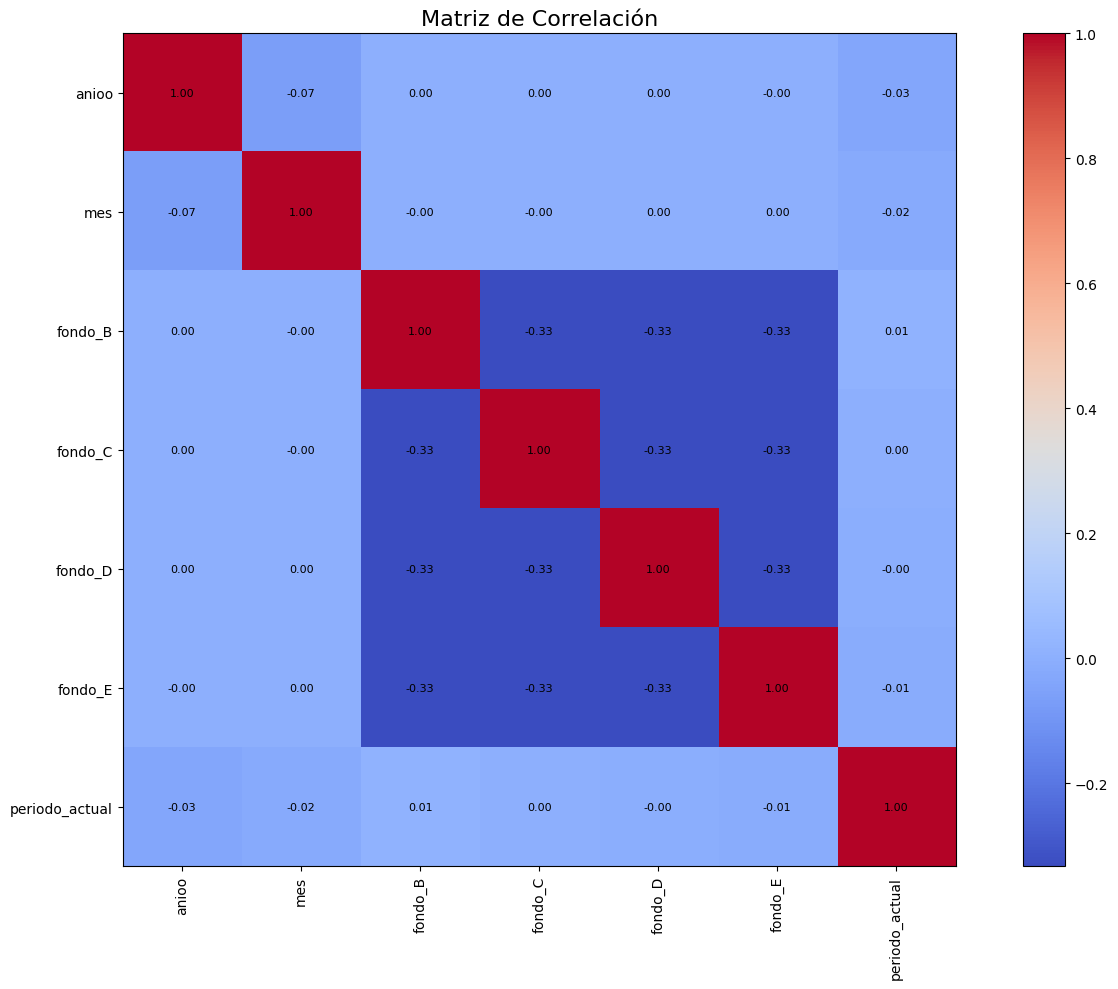

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Calcular la matriz de correlación
corr_matrix = df_encoded_onehot.corr()

# Crear la figura
plt.figure(figsize=(14, 10))

# Dibujar la matriz
plt.imshow(corr_matrix, cmap='coolwarm', interpolation='none')

# Agregar barra de colores
plt.colorbar()

# Títulos y etiquetas
plt.title('Matriz de Correlación', fontsize=16)
plt.xticks(range(len(corr_matrix)), corr_matrix.columns, rotation=90, fontsize=10)
plt.yticks(range(len(corr_matrix)), corr_matrix.columns, fontsize=10)

# Agregar los valores numéricos en cada celda
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        texto = f"{corr_matrix.iloc[i, j]:.2f}"
        plt.text(j, i, texto, ha='center', va='center', color='black', fontsize=8)

plt.tight_layout()
plt.show()


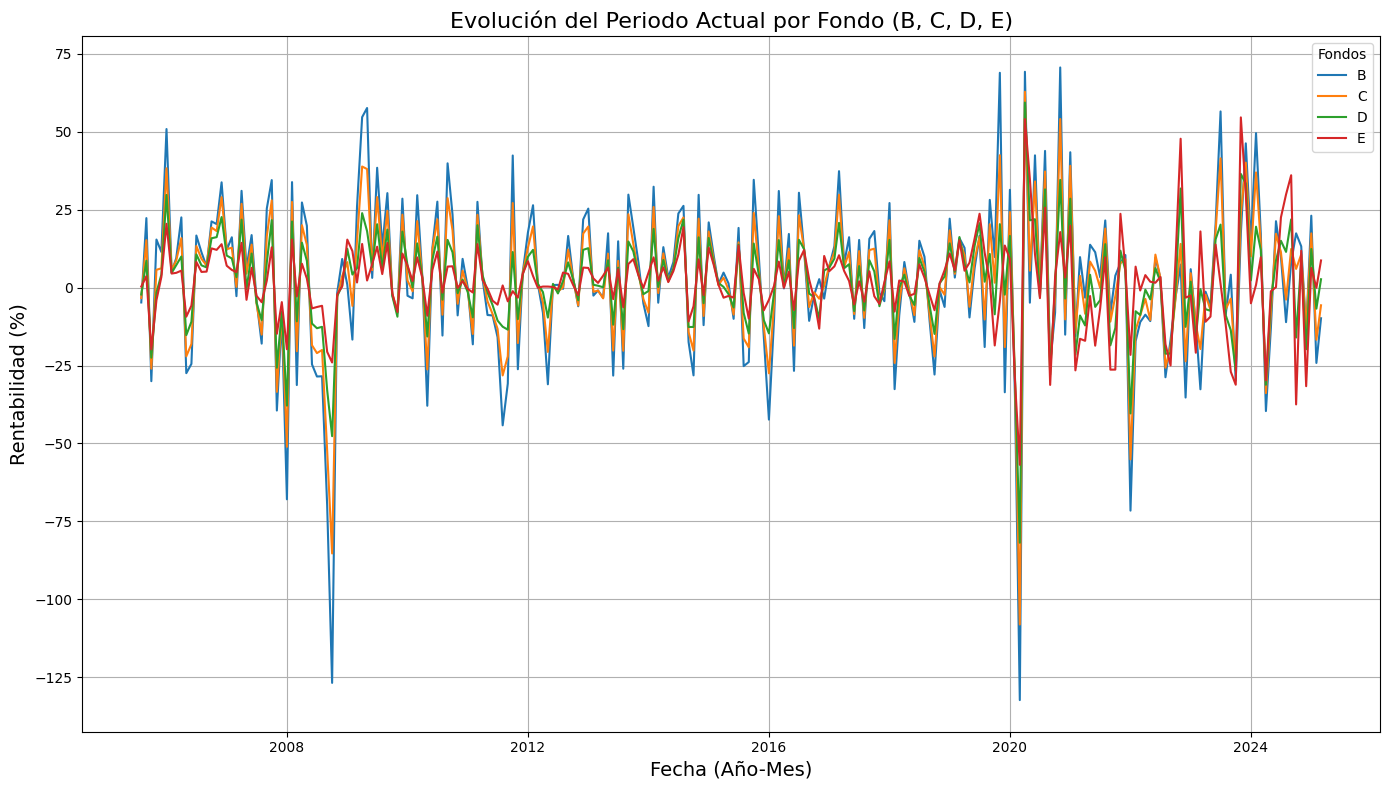

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Asegurar formato de fecha ---
df_encoded_onehot['fecha'] = pd.to_datetime(
    df_encoded_onehot['anioo'].astype(str) + '-' + df_encoded_onehot['mes'].astype(str) + '-01'
)

# --- Agrupar por fecha ---
# (Calculamos el promedio de periodo_actual por fecha para cada fondo)

# Multiplicar el valor de periodo_actual por la columna fondo que está activa
df_encoded_onehot['B_valor'] = df_encoded_onehot['fondo_B'] * df_encoded_onehot['periodo_actual']
df_encoded_onehot['B_valor'] = df_encoded_onehot['fondo_B'] * df_encoded_onehot['periodo_actual']
df_encoded_onehot['C_valor'] = df_encoded_onehot['fondo_C'] * df_encoded_onehot['periodo_actual']
df_encoded_onehot['D_valor'] = df_encoded_onehot['fondo_D'] * df_encoded_onehot['periodo_actual']
df_encoded_onehot['E_valor'] = df_encoded_onehot['fondo_E'] * df_encoded_onehot['periodo_actual']

# Agrupar sumando por fecha
df_agrupado = df_encoded_onehot.groupby('fecha')[['B_valor', 'C_valor', 'D_valor', 'E_valor']].sum()

# --- Graficar ---
plt.figure(figsize=(14, 8))

for columna in df_agrupado.columns:
    plt.plot(df_agrupado.index, df_agrupado[columna], label=columna.split('_')[0])

plt.title('Evolución del Periodo Actual por Fondo (B, C, D, E)', fontsize=16)
plt.xlabel('Fecha (Año-Mes)', fontsize=14)
plt.ylabel('Rentabilidad (%)', fontsize=14)
plt.legend(title='Fondos')
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import yfinance as yf
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

def predecir_fondo(df_afp_historico_limpio):
    # 1. --- Preparar fecha ---
    df_afp_historico_limpio['fecha'] = pd.to_datetime(
        df_afp_historico_limpio['anioo'].astype(str) + '-' + df_afp_historico_limpio['mes'].astype(str) + '-01'
    )
    df_afp_historico_limpio.set_index('fecha', inplace=True)

    # 2. --- Descargar precios de mercado ---
    tickers = tickers_final

    inicio = df_afp_historico_limpio.index.min().strftime('%Y-%m-%d')
    fin = df_afp_historico_limpio.index.max().strftime('%Y-%m-%d')

    precios = yf.download(tickers, start=inicio, end=fin, interval="1mo", group_by='ticker', auto_adjust=True)

    # 3. --- Crear DataFrame limpio de precios ---
    df_precios = pd.DataFrame(index=precios.index)
    for ticker in tickers:
        if ticker in precios.columns.get_level_values(0):
            df_precios[ticker] = precios[ticker]['Close']

    # 4. --- Merge de datos ---
    df_full = df_afp_historico_limpio.merge(df_precios, left_index=True, right_index=True, how='left')
    df_full.fillna(method='ffill', inplace=True)

    # 5. --- Preparar X e y ---
    X = df_full.drop(columns=['anioo', 'mes', 'fondo', 'periodo_actual'])
    y = df_full['fondo']

    # Codificar etiquetas
    encoder = LabelEncoder()
    y_encoded = encoder.fit_transform(y)

    # 6. --- Dividir en train/test ---
    X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, shuffle=True)

    # 7. --- Entrenar modelo (Random Forest Clasificación) ---
    modelo = RandomForestClassifier(n_estimators=200, random_state=42)
    modelo.fit(X_train, y_train)

    # 8. --- Evaluar ---
    y_pred = modelo.predict(X_test)

    print(f"\n📈 Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print("\n📋 Classification Report:")
    print(classification_report(y_test, y_pred, target_names=encoder.classes_))

    # 9. --- Mostrar importancia de variables ---
    importances = pd.Series(modelo.feature_importances_, index=X.columns)
    importances = importances.sort_values(ascending=False)

    print("\n🔍 Importancia de Indicadores Financieros para predecir Fondo:")
    print(importances)

    return modelo, encoder

# --- Ejecutar función ---
modelo, encoder = predecir_fondo(df_afp_historico_limpio)


/tmp/ipykernel_4255/51586797.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_afp_historico_limpio['fecha'] = pd.to_datetime(
[*********************100%***********************]  43 of 43 completed
/tmp/ipykernel_4255/51586797.py:32: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_full.fillna(method='ffill', inplace=True)



📈 Accuracy: 0.0785

📋 Classification Report:
              precision    recall  f1-score   support

           B       0.07      0.08      0.08       327
           C       0.09      0.10      0.09       326
           D       0.07      0.07      0.07       346
           E       0.08      0.07      0.07       352

    accuracy                           0.08      1351
   macro avg       0.08      0.08      0.08      1351
weighted avg       0.08      0.08      0.08      1351


🔍 Importancia de Indicadores Financieros para predecir Fondo:
^VIX        0.030883
SLV         0.030514
EURUSD=X    0.030127
EWZ         0.029158
CLP=X       0.028636
USO         0.028516
FXI         0.028263
JPY=X       0.027709
DBC         0.027458
ILF         0.027200
EWW         0.027098
GLD         0.027030
CNY=X       0.026395
DBA         0.025871
BRL=X       0.025715
MXN=X       0.025478
BNO         0.024712
COPX        0.024611
TLT         0.024348
IEF         0.024300
EWJ         0.024072
EEM         0.0

# guardar modelo

In [ ]:
!pip install joblib

In [ ]:
import joblib

# Guardar el modelo entrenado
joblib.dump(modelo, 'modelo_fondo_random_forest.pkl')

# Guardar el encoder también
joblib.dump(encoder, 'encoder_fondo_label.pkl')

print("✅ Modelo y Encoder guardados exitosamente.")


✅ Modelo y Encoder guardados exitosamente.


In [ ]:
import pandas as pd
import yfinance as yf
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Instalar XGBoost si no lo tienes:
# pip install xgboost
from xgboost import XGBClassifier

def predecir_fondo_mejorado(df_afp_historico_limpio):
    # 1. --- Preparar fecha ---
    df_afp_historico_limpio['fecha'] = pd.to_datetime(
        df_afp_historico_limpio['anioo'].astype(str) + '-' + df_afp_historico_limpio['mes'].astype(str) + '-01'
    )
    df_afp_historico_limpio.set_index('fecha', inplace=True)

    # 2. --- Descargar precios de mercado ---
    tickers = tickers_final

    inicio = df_afp_historico_limpio.index.min().strftime('%Y-%m-%d')
    fin = df_afp_historico_limpio.index.max().strftime('%Y-%m-%d')

    precios = yf.download(tickers, start=inicio, end=fin, interval="1mo", group_by='ticker', auto_adjust=True)

    # 3. --- Crear DataFrame limpio de precios ---
    df_precios = pd.DataFrame(index=precios.index)
    for ticker in tickers:
        if ticker in precios.columns.get_level_values(0):
            df_precios[ticker] = precios[ticker]['Close']

    # 4. --- Calcular % cambios
    df_precios = df_precios.pct_change()

    # 5. --- Merge de datos ---
    df_full = df_afp_historico_limpio.merge(df_precios, left_index=True, right_index=True, how='left')
    df_full.fillna(method='ffill', inplace=True)

    # 6. --- Preparar X e y ---
    X = df_full.drop(columns=['anioo', 'mes', 'fondo', 'periodo_actual'])
    y = df_full['fondo']

    # Codificar etiquetas
    encoder = LabelEncoder()
    y_encoded = encoder.fit_transform(y)

    # 7. --- Dividir en train/test ---
    X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, shuffle=True)

    # 8. --- Entrenar modelos ---
    rf_model = RandomForestClassifier(n_estimators=300, random_state=42)
    xgb_model = XGBClassifier(n_estimators=300, learning_rate=0.05, random_state=42, use_label_encoder=False, eval_metric='mlogloss')

    rf_model.fit(X_train, y_train)
    xgb_model.fit(X_train, y_train)

    # 9. --- Predicciones ---
    rf_pred = rf_model.predict(X_test)
    xgb_pred = xgb_model.predict(X_test)

    # 10. --- Resultados ---
    print("\n📈 Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
    print(classification_report(y_test, rf_pred, target_names=encoder.classes_))

    print("\n📈 XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))
    print(classification_report(y_test, xgb_pred, target_names=encoder.classes_))

    # 11. --- Matriz de Confusión
    plt.figure(figsize=(12,6))
    cm = confusion_matrix(y_test, rf_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=encoder.classes_, yticklabels=encoder.classes_)
    plt.title('Matriz de Confusión - Random Forest')
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.show()

    plt.figure(figsize=(12,6))
    cm = confusion_matrix(y_test, xgb_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=encoder.classes_, yticklabels=encoder.classes_)
    plt.title('Matriz de Confusión - XGBoost')
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.show()

    # 12. --- Importancia de variables RandomForest
    importances_rf = pd.Series(rf_model.feature_importances_, index=X.columns)
    importances_rf = importances_rf.sort_values(ascending=False)
    print("\n🔍 Importancia de Variables - Random Forest:")
    print(importances_rf.head(10))

    # 13. --- Importancia de variables XGBoost
    importances_xgb = pd.Series(xgb_model.feature_importances_, index=X.columns)
    importances_xgb = importances_xgb.sort_values(ascending=False)
    print("\n🔍 Importancia de Variables - XGBoost:")
    print(importances_xgb.head(10))

    return rf_model, xgb_model, encoder


/tmp/ipykernel_4255/1991531871.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_afp_historico_limpio['fecha'] = pd.to_datetime(
[*********************100%***********************]  43 of 43 completed
/tmp/ipykernel_4255/1991531871.py:41: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_full.fillna(method='ffill', inplace=True)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:22:51] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



📈 Random Forest Accuracy: 0.07846039970392302
              precision    recall  f1-score   support

           B       0.07      0.07      0.07       327
           C       0.09      0.09      0.09       326
           D       0.08      0.09      0.09       346
           E       0.08      0.07      0.07       352

    accuracy                           0.08      1351
   macro avg       0.08      0.08      0.08      1351
weighted avg       0.08      0.08      0.08      1351


📈 XGBoost Accuracy: 0.07846039970392302
              precision    recall  f1-score   support

           B       0.08      0.09      0.08       327
           C       0.08      0.11      0.09       326
           D       0.07      0.06      0.07       346
           E       0.08      0.06      0.07       352

    accuracy                           0.08      1351
   macro avg       0.08      0.08      0.08      1351
weighted avg       0.08      0.08      0.08      1351



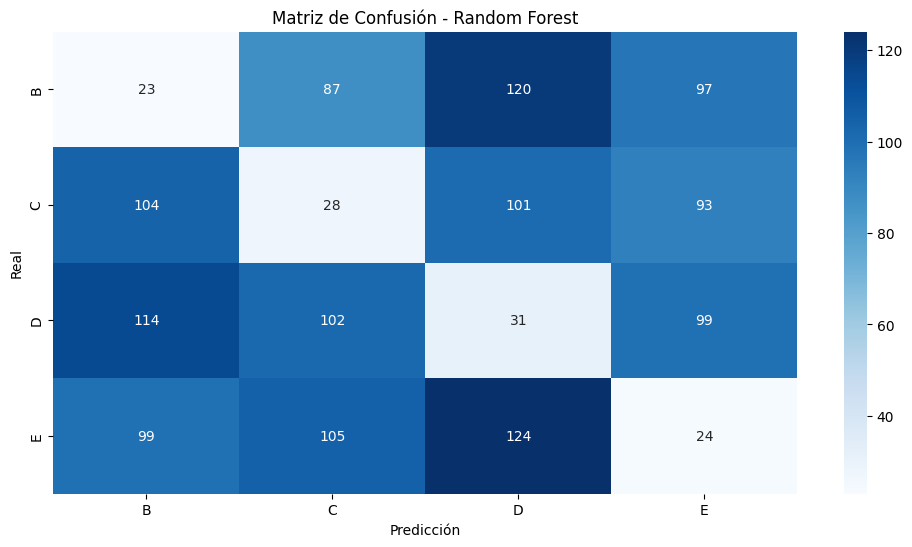

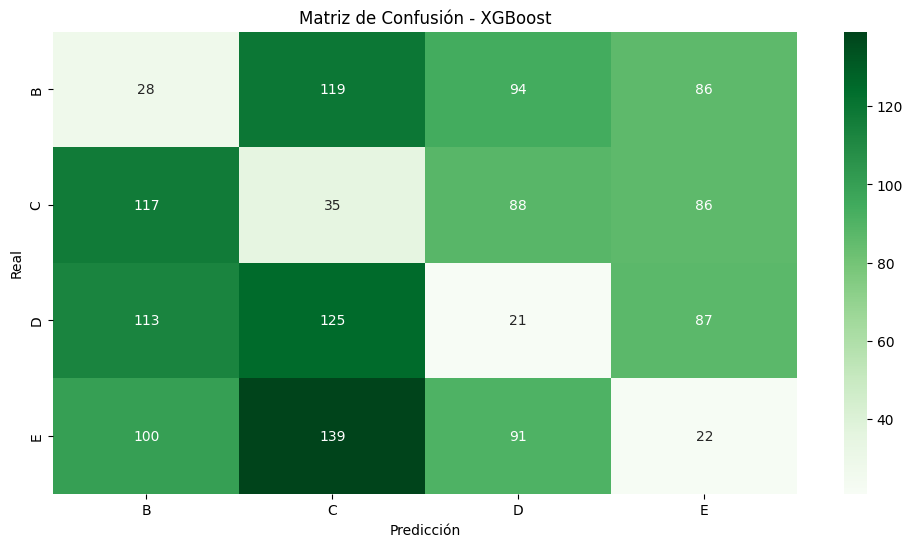


🔍 Importancia de Variables - Random Forest:
CNY=X       0.036439
EURUSD=X    0.035795
CLP=X       0.035788
JPY=X       0.034903
FXI         0.034716
MXN=X       0.034682
EWJ         0.034590
VPL         0.030923
VGK         0.029951
BRL=X       0.025676
dtype: float64

🔍 Importancia de Variables - XGBoost:
CNY=X    0.039399
FXI      0.038760
DBA      0.037073
IEF      0.034350
TIP      0.033294
JPY=X    0.032368
EWZ      0.032324
ILF      0.030810
CPER     0.029524
LIT      0.028167
dtype: float32


In [ ]:
rf_model, xgb_model, encoder = predecir_fondo_mejorado(df_afp_historico_limpio)


In [ ]:
import matplotlib.pyplot as plt

def graficar_importancia(importances, titulo="Importancia de Variables"):
    plt.figure(figsize=(10, 6))
    importances.head(15).sort_values().plot(kind='barh')
    plt.title(titulo)
    plt.xlabel("Importancia")
    plt.grid(True)
    plt.show()


In [ ]:
# Para Random Forest
importances_rf = pd.Series(rf_model.feature_importances_, index=rf_model.feature_names_in_).sort_values(ascending=False)

# Para XGBoost
importances_xgb = pd.Series(xgb_model.feature_importances_, index=xgb_model.feature_names_in_).sort_values(ascending=False)


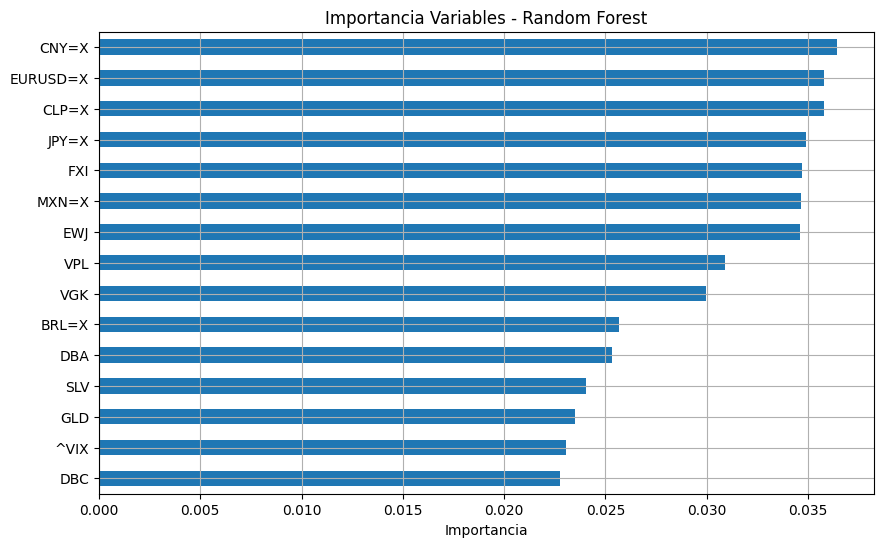

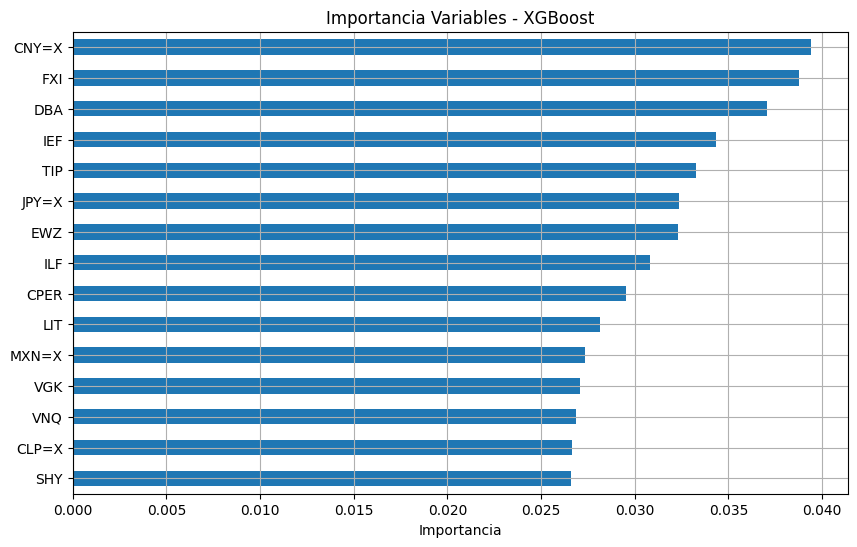

In [ ]:
graficar_importancia(importances_rf, "Importancia Variables - Random Forest")
graficar_importancia(importances_xgb, "Importancia Variables - XGBoost")

In [ ]:
def predecir_fondo_actual(modelo, encoder, fecha_actual=None):
    """
    Predice el fondo basado en precios de mercado a la fecha actual.
    """
    if fecha_actual is None:
        fecha_actual = datetime.today().strftime('%Y-%m-%d')

    # --- Descargar precios ---
    tickers = tickers_final

    precios_actuales = yf.download(tickers, start="2022-01-01", end=fecha_actual, interval="1mo", group_by='ticker', auto_adjust=True)

    # DataFrame limpio
    df_actual = pd.DataFrame(index=precios_actuales.index)
    for ticker in tickers:
        if ticker in precios_actuales.columns.get_level_values(0):
            df_actual[ticker] = precios_actuales[ticker]['Close']

    # Usamos la última fila disponible (último mes)
    ultimo_mes = df_actual.iloc[-2:].pct_change().iloc[-1]  # Cambio porcentual del mes
    ultimo_mes = ultimo_mes.fillna(0).to_frame().T

    # Predicción
    pred_encoded = modelo.predict(ultimo_mes)[0]
    pred_label = encoder.inverse_transform([pred_encoded])[0]

    print(f"Fecha predicha: {fecha_actual}")
    print(f"Fondo predicho: {pred_label}")

    return pred_label


In [ ]:
df_afp_historico_limpio

,anioo,mes,fondo,periodo_actual
fecha,,,,
2005-08-01,2005,8,B,-0.63
2005-08-01,2005,8,B,-0.62
2005-08-01,2005,8,B,-0.84
2005-08-01,2005,8,B,-0.79
2005-08-01,2005,8,B,-0.60
...,...,...,...,...
2025-03-01,2025,3,E,0.94
2025-03-01,2025,3,E,1.20
2025-03-01,2025,3,E,1.00


/tmp/ipykernel_4255/1991531871.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_afp_historico_limpio['fecha'] = pd.to_datetime(
[*********************100%***********************]  43 of 43 completed
/tmp/ipykernel_4255/1991531871.py:41: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_full.fillna(method='ffill', inplace=True)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:23:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



📈 Random Forest Accuracy: 0.07846039970392302
              precision    recall  f1-score   support

           B       0.07      0.07      0.07       327
           C       0.09      0.09      0.09       326
           D       0.08      0.09      0.09       346
           E       0.08      0.07      0.07       352

    accuracy                           0.08      1351
   macro avg       0.08      0.08      0.08      1351
weighted avg       0.08      0.08      0.08      1351


📈 XGBoost Accuracy: 0.07846039970392302
              precision    recall  f1-score   support

           B       0.08      0.09      0.08       327
           C       0.08      0.11      0.09       326
           D       0.07      0.06      0.07       346
           E       0.08      0.06      0.07       352

    accuracy                           0.08      1351
   macro avg       0.08      0.08      0.08      1351
weighted avg       0.08      0.08      0.08      1351



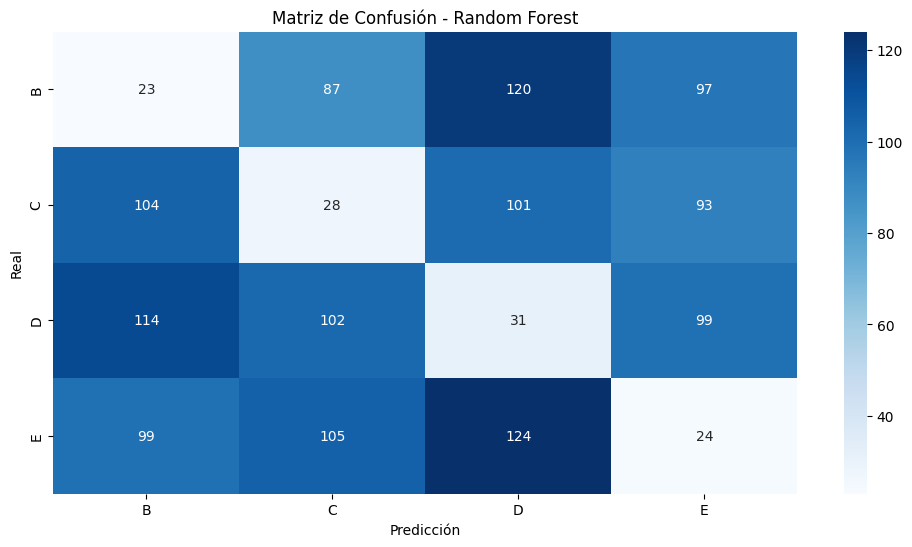

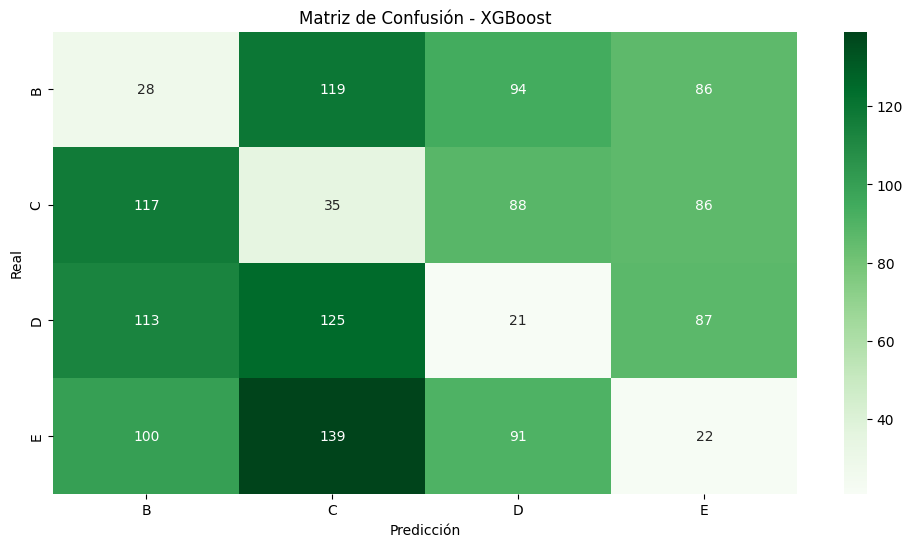


🔍 Importancia de Variables - Random Forest:
CNY=X       0.036439
EURUSD=X    0.035795
CLP=X       0.035788
JPY=X       0.034903
FXI         0.034716
MXN=X       0.034682
EWJ         0.034590
VPL         0.030923
VGK         0.029951
BRL=X       0.025676
dtype: float64

🔍 Importancia de Variables - XGBoost:
CNY=X    0.039399
FXI      0.038760
DBA      0.037073
IEF      0.034350
TIP      0.033294
JPY=X    0.032368
EWZ      0.032324
ILF      0.030810
CPER     0.029524
LIT      0.028167
dtype: float32


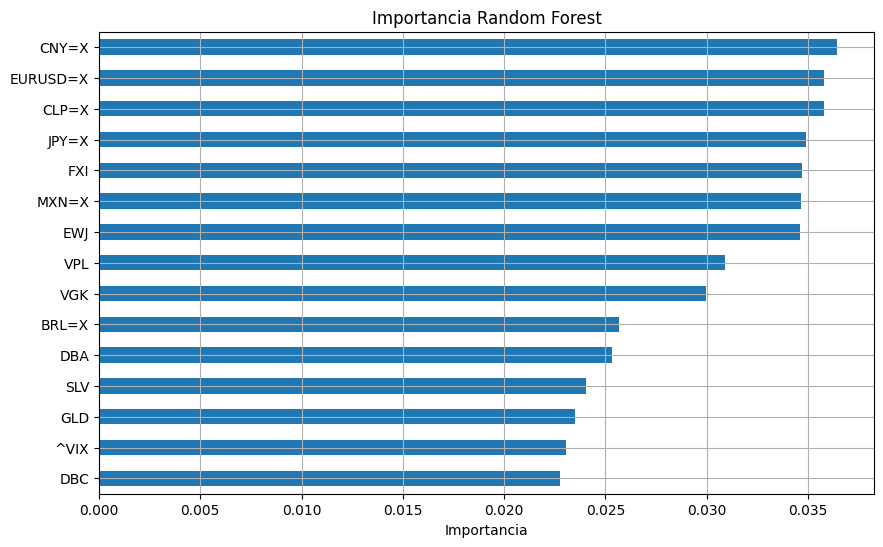

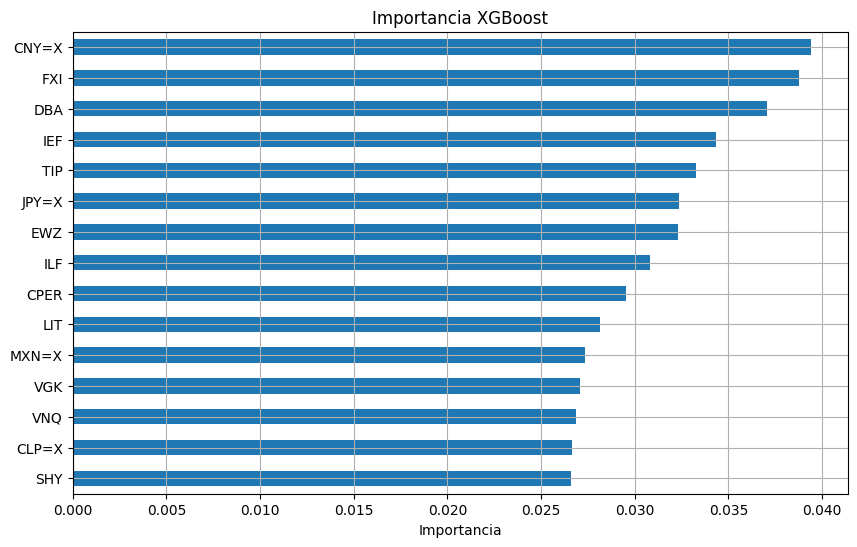

[*********************100%***********************]  43 of 43 completed


📅 Fecha predicha: 2026-03-20
🎯 Fondo predicho: E


In [ ]:
# Entrenamos el modelo antes:
rf_model, xgb_model, encoder = predecir_fondo_mejorado(df_afp_historico_limpio)

# Graficar importancia
graficar_importancia(importances_rf, "Importancia Random Forest")
graficar_importancia(importances_xgb, "Importancia XGBoost")

# Predecir fondo del mes actual
fondo_predicho = predecir_fondo_actual(rf_model, encoder)


In [ ]:
def entrenar_modelo_subida(df_afp_historico_limpio):
    import pandas as pd
    import yfinance as yf
    from datetime import datetime
    from sklearn.model_selection import train_test_split
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.metrics import accuracy_score, classification_report

    # Preparar fecha
    df_afp_historico_limpio['fecha'] = pd.to_datetime(
        df_afp_historico_limpio['anioo'].astype(str) + '-' + df_afp_historico_limpio['mes'].astype(str) + '-01'
    )
    df_afp_historico_limpio.set_index('fecha', inplace=True)

    # Descargar precios
    tickers = tickers_final

    inicio = df_afp_historico_limpio.index.min().strftime('%Y-%m-%d')
    fin = df_afp_historico_limpio.index.max().strftime('%Y-%m-%d')

    precios = yf.download(tickers, start=inicio, end=fin, interval="1mo", group_by='ticker', auto_adjust=True)

    df_precios = pd.DataFrame(index=precios.index)
    for ticker in tickers:
        if ticker in precios.columns.get_level_values(0):
            df_precios[ticker] = precios[ticker]['Close']

    # % cambios
    df_precios = df_precios.pct_change()

    # Merge
    df_full = df_afp_historico_limpio.merge(df_precios, left_index=True, right_index=True, how='left')
    df_full.fillna(method='ffill', inplace=True)

    # Target binario: sube o baja
    y = (df_full['periodo_actual'] > 0).astype(int)
    X = df_full.drop(columns=['anioo', 'mes', 'fondo', 'periodo_actual'])

    # Split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

    # Modelo
    modelo = RandomForestClassifier(n_estimators=300, random_state=42)
    modelo.fit(X_train, y_train)

    # Evaluar
    y_pred = modelo.predict(X_test)
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    return modelo


In [ ]:
def predecir_subida_actual(modelo, fecha_actual=None):
    from datetime import datetime
    import yfinance as yf
    import pandas as pd

    if fecha_actual is None:
        fecha_actual = datetime.today().strftime('%Y-%m-%d')

    # Descargar precios recientes
    tickers = tickers_final

    precios_actuales = yf.download(tickers, start="2023-01-01", end=fecha_actual, interval="1mo", group_by='ticker', auto_adjust=True)

    df_actual = pd.DataFrame(index=precios_actuales.index)
    for ticker in tickers:
        if ticker in precios_actuales.columns.get_level_values(0):
            df_actual[ticker] = precios_actuales[ticker]['Close']

    # Último cambio mensual
    ultimo_mes = df_actual.iloc[-2:].pct_change().iloc[-1]
    ultimo_mes = ultimo_mes.fillna(0).to_frame().T

    # Predicción
    pred = modelo.predict(ultimo_mes)[0]

    if pred == 1:
        print(f" Predicción para {fecha_actual}: El fondo SUBIRÁ.")
    else:
        print(f" Predicción para {fecha_actual}: El fondo BAJARÁ.")

    return pred


In [ ]:
# Entrenar modelo
modelo_subida = entrenar_modelo_subida(df_afp_historico_limpio)

# Predecir hoy
predecir_subida_actual(modelo_subida)


/tmp/ipykernel_4255/2561379201.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_afp_historico_limpio['fecha'] = pd.to_datetime(
[*********************100%***********************]  43 of 43 completed
/tmp/ipykernel_4255/2561379201.py:33: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_full.fillna(method='ffill', inplace=True)
[                       0%                       ]

📈 Accuracy: 0.8979

📋 Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.92      0.89       585
           1       0.93      0.88      0.91       766

    accuracy                           0.90      1351
   macro avg       0.90      0.90      0.90      1351
weighted avg       0.90      0.90      0.90      1351



[*********************100%***********************]  43 of 43 completed

📉 Predicción para 2026-03-20: El fondo BAJARÁ.


np.int64(0)

In [ ]:
import pandas as pd
import yfinance as yf
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

def entrenar_modelos_fondo_y_subida(df_afp_historico_limpio):
    """
    Entrena dos modelos:
    - Uno para predecir subida/bajada
    - Otro para predecir el fondo (B, C, D, E)
    """

    # Preparar fecha
    df_afp_historico_limpio['fecha'] = pd.to_datetime(
        df_afp_historico_limpio['anioo'].astype(str) + '-' + df_afp_historico_limpio['mes'].astype(str) + '-01'
    )
    df_afp_historico_limpio.set_index('fecha', inplace=True)

    # Descargar precios
    tickers = tickers_final


    inicio = df_afp_historico_limpio.index.min().strftime('%Y-%m-%d')
    fin = df_afp_historico_limpio.index.max().strftime('%Y-%m-%d')

    precios = yf.download(tickers, start=inicio, end=fin, interval="1mo", group_by='ticker', auto_adjust=True)

    df_precios = pd.DataFrame(index=precios.index)
    for ticker in tickers:
        if ticker in precios.columns.get_level_values(0):
            df_precios[ticker] = precios[ticker]['Close']

    df_precios = df_precios.pct_change()

    # Merge
    df_full = df_afp_historico_limpio.merge(df_precios, left_index=True, right_index=True, how='left')
    df_full.ffill(inplace=True)

    # Targets
    y_subida = (df_full['periodo_actual'] > 0).astype(int)
    y_fondo = df_full['fondo']

    encoder_fondo = LabelEncoder()
    y_fondo_encoded = encoder_fondo.fit_transform(y_fondo)

    X = df_full.drop(columns=['anioo', 'mes', 'fondo', 'periodo_actual'])

    # Split
    X_train, X_test, y_subida_train, y_subida_test = train_test_split(X, y_subida, test_size=0.2, random_state=42, shuffle=True)
    _, _, y_fondo_train, y_fondo_test = train_test_split(X, y_fondo_encoded, test_size=0.2, random_state=42, shuffle=True)

    # Modelos
    modelo_subida = RandomForestClassifier(n_estimators=300, random_state=42)
    modelo_fondo = RandomForestClassifier(n_estimators=300, random_state=42)

    modelo_subida.fit(X_train, y_subida_train)
    modelo_fondo.fit(X_train, y_fondo_train)

    # Evaluación rápida
    print("\n📈 Modelo Subida/Bajada:")
    y_subida_pred = modelo_subida.predict(X_test)
    print(f"Accuracy: {accuracy_score(y_subida_test, y_subida_pred):.4f}")
    print(classification_report(y_subida_test, y_subida_pred))

    print("\n📈 Modelo Fondo:")
    y_fondo_pred = modelo_fondo.predict(X_test)
    print(f"Accuracy: {accuracy_score(y_fondo_test, y_fondo_pred):.4f}")
    print(classification_report(y_fondo_test, y_fondo_pred, target_names=encoder_fondo.classes_))

    return modelo_subida, modelo_fondo, encoder_fondo


In [ ]:
def predecir_fondo_y_subida(modelo_subida, modelo_fondo, encoder_fondo, fecha_actual=None):
    """
    Predice si sube o baja y el fondo más probable usando precios de mercado actualizados.
    """

    if fecha_actual is None:
        fecha_actual = datetime.today().strftime('%Y-%m-%d')

    # Descargar precios
    tickers = tickers_final

    precios_actuales = yf.download(tickers, start="2022-01-01", end=fecha_actual, interval="1mo", group_by='ticker', auto_adjust=True)

    df_actual = pd.DataFrame(index=precios_actuales.index)
    for ticker in tickers:
        if ticker in precios_actuales.columns.get_level_values(0):
            df_actual[ticker] = precios_actuales[ticker]['Close']

    ultimo_mes = df_actual.iloc[-2:].pct_change().iloc[-1]
    ultimo_mes = ultimo_mes.fillna(0).to_frame().T

    # Predicción subida/bajada
    proba_subida = modelo_subida.predict_proba(ultimo_mes)[0]
    pred_subida = modelo_subida.predict(ultimo_mes)[0]

    # Predicción fondo
    pred_fondo_encoded = modelo_fondo.predict(ultimo_mes)[0]
    pred_fondo = encoder_fondo.inverse_transform([pred_fondo_encoded])[0]

    # Resultado
    print(f"\n📅 Fecha predicha: {fecha_actual}")
    if pred_subida == 1:
        print(f"📈 El fondo SUBIRÁ con {proba_subida[1]*100:.2f}% de probabilidad.")
    else:
        print(f"📉 El fondo BAJARÁ con {proba_subida[0]*100:.2f}% de probabilidad.")

    print(f"🏦 Fondo más probable: {pred_fondo}")

    return pred_subida, proba_subida, pred_fondo


In [ ]:
# Entrenar
modelo_subida, modelo_fondo, encoder_fondo = entrenar_modelos_fondo_y_subida(df_afp_historico_limpio)

# Predecir
predecir_fondo_y_subida(modelo_subida, modelo_fondo, encoder_fondo)


/tmp/ipykernel_4255/3511837311.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_afp_historico_limpio['fecha'] = pd.to_datetime(
[*********************100%***********************]  43 of 43 completed



📈 Modelo Subida/Bajada:
Accuracy: 0.8979
              precision    recall  f1-score   support

           0       0.86      0.92      0.89       585
           1       0.93      0.88      0.91       766

    accuracy                           0.90      1351
   macro avg       0.90      0.90      0.90      1351
weighted avg       0.90      0.90      0.90      1351


📈 Modelo Fondo:
Accuracy: 0.0785
              precision    recall  f1-score   support

           B       0.07      0.08      0.07       327
           C       0.08      0.09      0.08       326
           D       0.08      0.09      0.08       346
           E       0.08      0.07      0.07       352

    accuracy                           0.08      1351
   macro avg       0.08      0.08      0.08      1351
weighted avg       0.08      0.08      0.08      1351



[*********************100%***********************]  43 of 43 completed


📅 Fecha predicha: 2026-03-20
📉 El fondo BAJARÁ con 80.97% de probabilidad.
🏦 Fondo más probable: E


(np.int64(0), array([0.80968131, 0.19031869]), 'E')

In [ ]:
def predecir_todos_los_fondos(modelo_subida, modelo_fondo, encoder_fondo, fecha_actual=None):
    """
    Predice subida/bajada para todos los fondos posibles (B, C, D, E) a la fecha actual.
    Devuelve un DataFrame con resultados.
    """
    import pandas as pd
    from datetime import datetime
    import yfinance as yf

    if fecha_actual is None:
        fecha_actual = datetime.today().strftime('%Y-%m-%d')

    # Descargar precios
    tickers = tickers_final
    precios_actuales = yf.download(tickers, start="2022-01-01", end=fecha_actual, interval="1mo", group_by='ticker', auto_adjust=True)

    df_actual = pd.DataFrame(index=precios_actuales.index)
    for ticker in tickers:
        if ticker in precios_actuales.columns.get_level_values(0):
            df_actual[ticker] = precios_actuales[ticker]['Close']

    ultimo_mes = df_actual.iloc[-2:].pct_change().iloc[-1]
    ultimo_mes = ultimo_mes.fillna(0).to_frame().T

    # --- Predicción subida/bajada general ---
    proba_subida = modelo_subida.predict_proba(ultimo_mes)[0]
    pred_subida = modelo_subida.predict(ultimo_mes)[0]

    # --- Predicción fondo más probable ---
    pred_fondo_encoded = modelo_fondo.predict(ultimo_mes)[0]
    pred_fondo = encoder_fondo.inverse_transform([pred_fondo_encoded])[0]

    # --- DataFrame para todos los fondos ---
    fondos = encoder_fondo.classes_

    resultados = []

    for fondo in fondos:
        # No cambia la predicción de subida/bajada por fondo (en esta arquitectura),
        # pero podrías diferenciar si en el futuro cada fondo tiene su propio modelo.

        resultados.append({
            'fecha': fecha_actual,
            'fondo': fondo,
            'subida_predicha': pred_subida,
            'probabilidad_subida': proba_subida[1] * 100,
            'probabilidad_bajada': proba_subida[0] * 100,
            'fondo_predicho': pred_fondo
        })

    df_resultados = pd.DataFrame(resultados)

    print("\n📊 Predicciones actuales por fondo:")
    display(df_resultados)

    return df_resultados


In [ ]:
# Entrenar modelos
modelo_subida, modelo_fondo, encoder_fondo = entrenar_modelos_fondo_y_subida(df_afp_historico_limpio)

# Predecir todos los fondos
df_predicciones = predecir_todos_los_fondos(modelo_subida, modelo_fondo, encoder_fondo)

/tmp/ipykernel_4255/3511837311.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_afp_historico_limpio['fecha'] = pd.to_datetime(
[*********************100%***********************]  43 of 43 completed



📈 Modelo Subida/Bajada:
Accuracy: 0.8979
              precision    recall  f1-score   support

           0       0.86      0.92      0.89       585
           1       0.93      0.88      0.91       766

    accuracy                           0.90      1351
   macro avg       0.90      0.90      0.90      1351
weighted avg       0.90      0.90      0.90      1351


📈 Modelo Fondo:
Accuracy: 0.0785
              precision    recall  f1-score   support

           B       0.07      0.07      0.07       327
           C       0.08      0.08      0.08       326
           D       0.08      0.09      0.09       346
           E       0.08      0.07      0.08       352

    accuracy                           0.08      1351
   macro avg       0.08      0.08      0.08      1351
weighted avg       0.08      0.08      0.08      1351



[*********************100%***********************]  43 of 43 completed



📊 Predicciones actuales por fondo:


,fecha,fondo,subida_predicha,probabilidad_subida,probabilidad_bajada,fondo_predicho
0,2026-03-20,B,0,19.096575,80.903425,E
1,2026-03-20,C,0,19.096575,80.903425,E
2,2026-03-20,D,0,19.096575,80.903425,E
3,2026-03-20,E,0,19.096575,80.903425,E


In [ ]:
df_predicciones

,fecha,fondo,subida_predicha,probabilidad_subida,probabilidad_bajada,fondo_predicho
0,2026-03-20,B,0,19.096575,80.903425,E
1,2026-03-20,C,0,19.096575,80.903425,E
2,2026-03-20,D,0,19.096575,80.903425,E
3,2026-03-20,E,0,19.096575,80.903425,E


DASSA

In [ ]:
def entrenar_y_guardar_modelos_por_fondo(df_afp_historico_limpio, ruta_guardado='./modelos_fondos'):
    """
    Entrena un modelo Random Forest para cada fondo (B, C, D, E) y los guarda en archivos .pkl.
    Retorna un diccionario de los modelos entrenados.
    """
    import pandas as pd
    import os
    import joblib
    import yfinance as yf
    from sklearn.model_selection import train_test_split
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.metrics import accuracy_score, classification_report

    # Crear carpeta si no existe
    if not os.path.exists(ruta_guardado):
        os.makedirs(ruta_guardado)

    # Preparar fecha
    df_afp_historico_limpio['fecha'] = pd.to_datetime(
        df_afp_historico_limpio['anioo'].astype(str) + '-' + df_afp_historico_limpio['mes'].astype(str) + '-01'
    )
    df_afp_historico_limpio.set_index('fecha', inplace=True)

    # Descargar precios
    tickers = tickers_final
    inicio = df_afp_historico_limpio.index.min().strftime('%Y-%m-%d')
    fin = df_afp_historico_limpio.index.max().strftime('%Y-%m-%d')

    precios = yf.download(tickers, start=inicio, end=fin, interval="1mo", group_by='ticker', auto_adjust=True)

    df_precios = pd.DataFrame(index=precios.index)
    for ticker in tickers:
        if ticker in precios.columns.get_level_values(0):
            df_precios[ticker] = precios[ticker]['Close']

    df_precios = df_precios.pct_change()

    # Merge
    df_full = df_afp_historico_limpio.merge(df_precios, left_index=True, right_index=True, how='left')
    df_full.ffill(inplace=True)

    modelos = {}

    for fondo in ['B', 'C', 'D', 'E']:
        print(f"\n🔵 Entrenando modelo para fondo {fondo}...")

        df_fondo = df_full[df_full['fondo'] == fondo]

        if df_fondo.empty:
            print(f"⚠️ No hay datos para el fondo {fondo}. Se omitirá.")
            continue

        X = df_fondo.drop(columns=['anioo', 'mes', 'fondo', 'periodo_actual'])
        y = (df_fondo['periodo_actual'] > 0).astype(int)  # 1 si sube, 0 si baja

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

        modelo = RandomForestClassifier(n_estimators=300, random_state=42)
        modelo.fit(X_train, y_train)

        y_pred = modelo.predict(X_test)
        print(f"📈 Fondo {fondo} - Accuracy: {accuracy_score(y_test, y_pred):.4f}")
        print(classification_report(y_test, y_pred))

        # Guardar modelo
        ruta_modelo = os.path.join(ruta_guardado, f'modelo_fondo_{fondo}.pkl')
        joblib.dump(modelo, ruta_modelo)
        print(f"💾 Modelo fondo {fondo} guardado en {ruta_modelo}")

        modelos[fondo] = modelo

    return modelos


In [ ]:
def predecir_subida_por_fondo(modelos, fecha_actual=None):
    """
    Predice si cada fondo sube o baja usando los modelos entrenados individualmente.
    Devuelve un DataFrame resumen.
    """
    import pandas as pd
    from datetime import datetime
    import yfinance as yf

    if fecha_actual is None:
        fecha_actual = datetime.today().strftime('%Y-%m-%d')
        #fecha_actual = datetime.today().strftime('2025-05-12')


    tickers = tickers_final

    precios_actuales = yf.download(tickers, start="2022-01-01", end=fecha_actual, interval="1mo", group_by='ticker', auto_adjust=True)

    df_actual = pd.DataFrame(index=precios_actuales.index)
    for ticker in tickers:
        if ticker in precios_actuales.columns.get_level_values(0):
            df_actual[ticker] = precios_actuales[ticker]['Close']

    ultimo_mes = df_actual.iloc[-2:].pct_change().iloc[-1]
    ultimo_mes = ultimo_mes.fillna(0).to_frame().T

    resultados = []

    for fondo, modelo in modelos.items():
        proba = modelo.predict_proba(ultimo_mes)[0]
        pred = modelo.predict(ultimo_mes)[0]

        resultados.append({
            'fecha': fecha_actual,
            'fondo': fondo,
            'subida_predicha': pred,
            'probabilidad_subida': proba[1] * 100,
            'probabilidad_bajada': proba[0] * 100,
        })

    df_resultados = pd.DataFrame(resultados)

    print("\n📊 Predicciones fondo por fondo:")
    display(df_resultados)

    return df_resultados


In [ ]:
# Entrenar modelos por fondo
modelos_por_fondo = entrenar_y_guardar_modelos_por_fondo(df_afp_historico_limpio)

# Predecir todos los fondos
df_predicciones = predecir_subida_por_fondo(modelos_por_fondo)

/tmp/ipykernel_4255/3487893047.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_afp_historico_limpio['fecha'] = pd.to_datetime(
[*********************100%***********************]  43 of 43 completed



🔵 Entrenando modelo para fondo B...
📈 Fondo B - Accuracy: 0.9970
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       161
           1       0.99      1.00      1.00       177

    accuracy                           1.00       338
   macro avg       1.00      1.00      1.00       338
weighted avg       1.00      1.00      1.00       338

💾 Modelo fondo B guardado en ./modelos_fondos/modelo_fondo_B.pkl

🔵 Entrenando modelo para fondo C...
📈 Fondo C - Accuracy: 0.9941
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       165
           1       0.99      0.99      0.99       173

    accuracy                           0.99       338
   macro avg       0.99      0.99      0.99       338
weighted avg       0.99      0.99      0.99       338

💾 Modelo fondo C guardado en ./modelos_fondos/modelo_fondo_C.pkl

🔵 Entrenando modelo para fondo D...
📈 Fondo D - Accuracy: 0.9793
              prec

[*********************100%***********************]  43 of 43 completed



📊 Predicciones fondo por fondo:


,fecha,fondo,subida_predicha,probabilidad_subida,probabilidad_bajada
0,2026-03-20,B,0,25.358995,74.641005
1,2026-03-20,C,0,13.366667,86.633333
2,2026-03-20,D,0,11.157588,88.842412
3,2026-03-20,E,0,37.700914,62.299086


In [ ]:
df_predicciones

,fecha,fondo,subida_predicha,probabilidad_subida,probabilidad_bajada
0,2026-03-20,B,0,25.358995,74.641005
1,2026-03-20,C,0,13.366667,86.633333
2,2026-03-20,D,0,11.157588,88.842412
3,2026-03-20,E,0,37.700914,62.299086


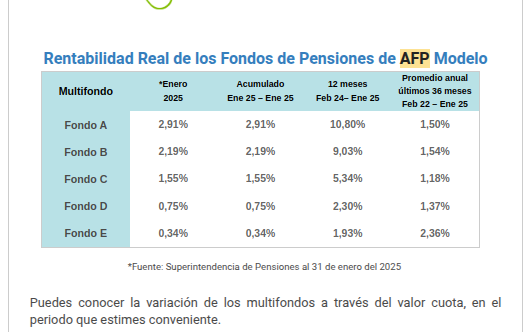

In [ ]:
def simular_predicciones_por_fechas(modelos, fechas):
    """
    Simula predicciones de subida/bajada para múltiples fechas.
    Devuelve un DataFrame con todas las simulaciones.
    """
    import pandas as pd

    resultados_totales = []

    for fecha in fechas:
        print(f"\n🔎 Simulando para fecha {fecha}...")
        df_prediccion = predecir_subida_por_fondo(modelos, fecha_actual=fecha)
        resultados_totales.append(df_prediccion)

    df_simulaciones = pd.concat(resultados_totales, ignore_index=True)

    print("\n✅ Simulaciones completadas.")
    display(df_simulaciones)

    return df_simulaciones


In [ ]:
from datetime import datetime, timedelta

# Fecha de inicio y fin
fecha_inicio = datetime.strptime("2026-03-04", "%Y-%m-%d")
fecha_fin = datetime.today()

# Lista de fechas hábiles (lunes a viernes)
fechas_a_simular = []
fecha_actual = fecha_inicio

while fecha_actual <= fecha_fin:
    if fecha_actual.weekday() < 5:  # 0 = lunes, 4 = viernes
        fechas_a_simular.append(fecha_actual.strftime("%Y-%m-%d"))
    fecha_actual += timedelta(days=1)

print(fechas_a_simular)


['2026-03-04', '2026-03-05', '2026-03-06', '2026-03-09', '2026-03-10', '2026-03-11', '2026-03-12', '2026-03-13', '2026-03-16', '2026-03-17', '2026-03-18', '2026-03-19', '2026-03-20']


In [ ]:
# Simular predicciones
df_simulaciones = simular_predicciones_por_fechas(modelos_por_fondo, fechas_a_simular)

[                       0%                       ]


🔎 Simulando para fecha 2026-03-04...


[*********************100%***********************]  43 of 43 completed



📊 Predicciones fondo por fondo:


,fecha,fondo,subida_predicha,probabilidad_subida,probabilidad_bajada
0,2026-03-04,B,0,25.358995,74.641005
1,2026-03-04,C,0,13.366667,86.633333
2,2026-03-04,D,0,11.157588,88.842412
3,2026-03-04,E,0,37.700914,62.299086


...

[*********************100%***********************]  43 of 43 completed


📊 Predicciones fondo por fondo:


,fecha,fondo,subida_predicha,probabilidad_subida,probabilidad_bajada
0,2026-03-20,B,0,25.358995,74.641005
1,2026-03-20,C,0,13.366667,86.633333
2,2026-03-20,D,0,11.157588,88.842412
3,2026-03-20,E,0,37.700914,62.299086



✅ Simulaciones completadas.


,fecha,fondo,subida_predicha,probabilidad_subida,probabilidad_bajada
0,2026-03-04,B,0,25.358995,74.641005
1,2026-03-04,C,0,13.366667,86.633333
2,2026-03-04,D,0,11.157588,88.842412
3,2026-03-04,E,0,37.700914,62.299086
4,2026-03-05,B,0,25.358995,74.641005
5,2026-03-05,C,0,13.366667,86.633333
6,2026-03-05,D,0,11.157588,88.842412
7,2026-03-05,E,0,37.700914,62.299086
8,2026-03-06,B,0,25.358995,74.641005
9,2026-03-06,C,0,13.366667,86.633333


https://www.spensiones.cl/apps/rentabilidad/getRentabilidad.php?tiprent=FP&template=0

| fecha       | fondo | subida_predicha | probabilidad_subida | probabilidad_bajada |
|:------------|:------|:----------------|:--------------------|:--------------------|
| 2019-11-01  | B     | 1                | 99.666667            | 0.333333             |
| 2019-11-01  | C     | 1                | 100.000000           | 0.000000             |
| 2019-11-01  | D     | 0                | 2.333333             | 97.666667            |
| 2019-11-01  | E     | 0                | 2.666667             | 97.333333            |


# RENTABILIDAD REAL DE LOS FONDOS DE PENSIONES
## Noviembre de 2019

| Fondo | Rentabilidad Nov 2019 | Acumulado Ene-Nov 2019 | Últimos 12 meses | Promedio Anual Sistema |
|:------|:----------------------|:-----------------------|:-----------------|:------------------------|
| A     | 8,55%                 | 22,50%                 | 21,47%           | 6,85%                   |
| B     | 5,23%                 | 17,73%                 | 17,35%           | 5,78%                   |
| C     | 2,33%                 | 15,28%                 | 15,91%           | 5,32%                   |
| D     | -0,95%                | 11,08%                 | 12,00%           | 4,65%                   |
| E     | -2,60%                | 6,17%                  | 7,17%            | 4,64%                   |


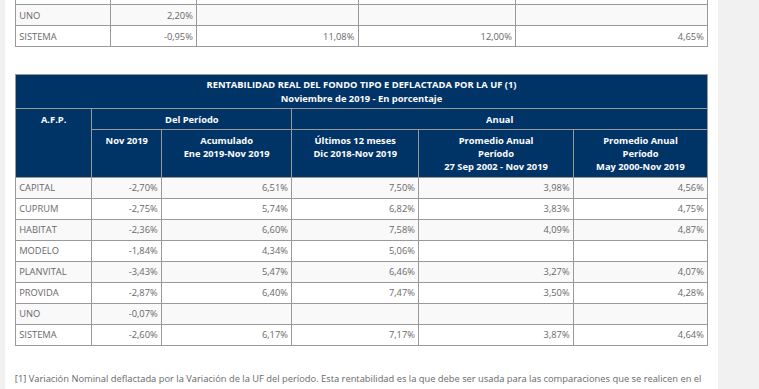

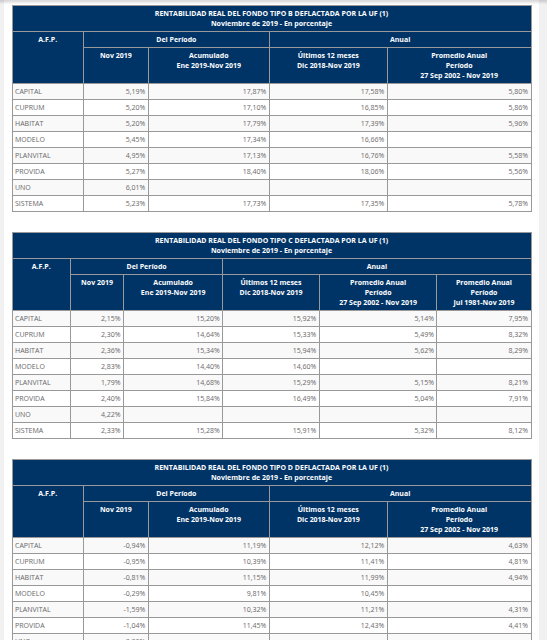

In [ ]:
df_simulaciones

,fecha,fondo,subida_predicha,probabilidad_subida,probabilidad_bajada
0,2026-03-04,B,0,25.358995,74.641005
1,2026-03-04,C,0,13.366667,86.633333
2,2026-03-04,D,0,11.157588,88.842412
3,2026-03-04,E,0,37.700914,62.299086
4,2026-03-05,B,0,25.358995,74.641005
5,2026-03-05,C,0,13.366667,86.633333
6,2026-03-05,D,0,11.157588,88.842412
7,2026-03-05,E,0,37.700914,62.299086
8,2026-03-06,B,0,25.358995,74.641005
9,2026-03-06,C,0,13.366667,86.633333
